In [22]:
# ============================================================
# Feature Engineering + XGBoost: PM2.5 Prediction
# ============================================================
 
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
 
warnings.filterwarnings("ignore")
 
# ── Style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3347",
    "axes.labelcolor":  "#c8cfe0",
    "xtick.color":      "#6b7394",
    "ytick.color":      "#6b7394",
    "text.color":       "#c8cfe0",
    "grid.color":       "#2e3347",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "axes.titlesize":   11,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
})
ACCENT  = "#5b7cf6"
ACCENT2 = "#f26d6d"
ACCENT3 = "#43d1a0"
ACCENT4 = "#f4b942"
PALE    = "#2e3347"
 
 
# ============================================================
# CONFIG
# ============================================================
FILE       = "../data/processed/openmeteo_firms_merged.csv"
TRAIN_END  = "2024-06-30 23:00:00"
VAL_END    = "2024-12-31 23:00:00"
LAG_HOURS  = [1, 2, 3, 6, 12, 24, 48, 72]
FIRE_LAGS  = [24, 48, 72]
WINDOWS    = [3, 6, 12, 24, 48, 168]

In [23]:
# HELPER: build features สำหรับ 1 split
# ใช้ history_df เพื่อคำนวณ lag ของ row แรก ๆ ใน target_df

def build_features(target_df, history_df, province_mean_map, le):
    """
    target_df   : dataframe ที่ต้องการสร้าง features (train / val / test)
    history_df  : dataframe ก่อนหน้า target_df (สำหรับ lag lookup)
    province_mean_map : dict {province: mean_pm25} คำนวณจาก train เท่านั้น
    le          : fitted LabelEncoder
    """
    results = []

    for prov, grp in target_df.groupby('Province'):
        # ดึง history ของจังหวัดนี้
        hist = history_df[history_df['Province'] == prov].sort_values('Datetime')
        cur = grp.sort_values('Datetime').copy()
        
        # ต่อ history ไว้ด้านหน้าเพื่อคำนวณ lag/rolling ได้
        combined = pd.concat([hist, cur], ignore_index=True)
        n_hist = len(hist)

        # Time Features
        combined['year'] = combined['Datetime'].dt.year
        combined['month'] = combined['Datetime'].dt.month
        combined['day'] = combined['Datetime'].dt.day
        combined['hour'] = combined['Datetime'].dt.hour
        combined['dayofyear'] = combined['Datetime'].dt.dayofyear
        combined['is_haze_season'] = combined['month'].isin([3, 4]).astype(int)
        combined['hour_sin'] = np.sin(2 * np.pi * combined['hour'] / 24)
        combined['hour_cos'] = np.cos(2 * np.pi * combined['hour'] / 24)
        combined['month_sin'] = np.sin(2 * np.pi * combined['month'] / 12)
        combined['month_cos'] = np.cos(2 * np.pi * combined['month'] / 12)
        combined['day_sin'] = np.sin(2 * np.pi * combined['day'] / 365)
        combined['day_cos'] = np.cos(2 * np.pi * combined['day'] / 365)
        combined['wind_dir_sin'] = np.sin(np.radians(combined['wind_direction_10m']))
        combined['wind_dir_cos'] = np.cos(np.radians(combined['wind_direction_10m']))

        # Lag Features
        for lag in LAG_HOURS:
            combined[f'pm25_lag_{lag}h'] = combined['PM25'].shift(lag)
        
        for lag in FIRE_LAGS:
            combined[f'hotspot_lag_{lag}h'] = combined['hotspot_count'].shift(lag)
            combined[f'frp_sum_lag_{lag}h'] = combined['frp_sum'].shift(lag)

        # Rolling Features
        for w in WINDOWS:
            combined[f'pm25_roll_mean_{w}h'] = combined['PM25'].shift(1).rolling(window=w, min_periods=1).mean()
            combined[f'pm25_roll_std_{w}h'] = combined['PM25'].shift(1).rolling(window=w, min_periods=1).std()
            combined[f'pm25_roll_max_{w}h'] = combined['PM25'].shift(1).rolling(window=w, min_periods=1).max()

            for w in [24, 48 ,168]:
                combined[f'hotspot_roll_sum_{w}h'] = combined['hotspot_count'].shift(1).rolling(window=w, min_periods=1).sum()
                combined[f'frp_roll_sum_{w}h'] = combined['frp_sum'].shift(1).rolling(window=w, min_periods=1).sum()

            # Log transform
            combined['hotspot_log'] = np.log1p(combined['hotspot_count'])
            combined['frp_sum_log'] = np.log1p(combined['frp_sum'])
            combined['frp_mean_log'] = np.log1p(combined['frp_mean'])
            combined['precipitation_log'] = np.log1p(combined['precipitation'])
            for lag in FIRE_LAGS:
                combined[f'hotspot_log_lag_{lag}h'] = np.log1p(combined[f'hotspot_lag_{lag}h']).fillna(0)

            # Delta features
            combined["pm25_delta_1h"]      = combined["PM25"].diff(1).shift(1)
            combined["pm25_delta_24h"]     = combined["PM25"].diff(24).shift(1)
            combined["humidity_delta_1h"]  = combined["relative_humidity_2m"].diff(1)
            combined["humidity_delta_24h"] = combined["relative_humidity_2m"].diff(24)
 
            # ── Interaction ──
            combined["temp_x_humidity"] = combined["temperature_2m"] * combined["relative_humidity_2m"] / 100
            combined["hotspot_x_haze"]  = combined["hotspot_log"] * combined["is_haze_season"]
            combined["frp_x_haze"]      = combined["frp_sum_log"] * combined["is_haze_season"]
            combined["wind_x_hotspot"]  = combined["wind_speed_10m"] * combined["hotspot_log"]
 
            # ── Province encoding ──
            combined["province_label"]      = le.transform([prov] * len(combined))[0]
            combined["province_target_enc"] = province_mean_map.get(prov, 0)
 
            # ตัดเอาเฉพาะ target rows (ไม่รวม history)
            result = combined.iloc[n_hist:].copy()
            results.append(result)
 
        return pd.concat(results).sort_values("Datetime").reset_index(drop=True)

### Load & Spilt Raw data

In [24]:
print("=" * 60)
print("  XGBoost PM2.5 — Fixed Pipeline")
print("=" * 60)
print("\n[1] Loading & splitting raw data...")
 
df = pd.read_csv(FILE)
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values(["Province", "Datetime"]).reset_index(drop=True)
 
df_train_raw = df[df["Datetime"] <= TRAIN_END].copy()
df_val_raw   = df[(df["Datetime"] > TRAIN_END) & (df["Datetime"] <= VAL_END)].copy()
df_test_raw  = df[df["Datetime"] > VAL_END].copy()
 
print(f"  Train raw : {len(df_train_raw):,} rows")
print(f"  Val raw   : {len(df_val_raw):,} rows")
print(f"  Test raw  : {len(df_test_raw):,} rows")

  XGBoost PM2.5 — Fixed Pipeline

[1] Loading & splitting raw data...
  Train raw : 105,024 rows
  Val raw   : 35,328 rows
  Test raw  : 70,080 rows


### FIT ENCODERS

In [25]:
print("\n[2] Fitting encoders on train only...")

le = LabelEncoder()
le.fit(df_train_raw["Province"])

# Province target encoding (ใช้เฉพาะ train เพื่อป้องกัน leakage)
province_mean_map = df_train_raw.groupby("Province")["PM25"].mean().to_dict()
print(f' Province mean map: {province_mean_map} ')


[2] Fitting encoders on train only...
 Province mean map: {'Chiang Mai': 21.587774223034735, 'Chiang Rai': 19.978260207190736, 'Lampang': 18.251279707495428, 'Lamphun': 17.79868982327849, 'Mae Hong Son': 12.911837294332724, 'Nan': 18.212416209628277, 'Phayao': 17.143692870201097, 'Phrae': 17.761144119439365} 


### BUILD FEATURES (แยกทำต่อ split โดยใช้ history ก่อนหน้า)

In [26]:
print("\n[3] Building features per split...")

# Train ใช้ history จากตัวเอง (row ก่อนหน้า same province)
print(' Building train features... ')
df_train_feat = build_features(df_train_raw, df_train_raw, province_mean_map, le)

# Val ใช้ history จาก train (เพื่อให้มี lag/rolling features)
print(' Building val features... ')
df_val_feat = build_features(df_val_raw, df_train_raw, province_mean_map, le)

# Test ใช้ history จาก train + val
print(' Building test features...')
history_for_test = pd.concat([df_train_raw, df_val_raw])
df_test_feat = build_features(df_test_raw, history_for_test, province_mean_map, le)


[3] Building features per split...
 Building train features... 


 Building val features... 
 Building test features...


### Feature List

In [27]:
STATIC_FEATURES = [
    "temperature_2m", "relative_humidity_2m", "precipitation_log",
    "surface_pressure", "wind_speed_10m", "wind_dir_sin", "wind_dir_cos",
    "hotspot_log", "frp_sum_log", "frp_mean_log",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day_sin", "day_cos", "is_haze_season", "year",
    "province_label", "province_target_enc",
    "temp_x_humidity", "hotspot_x_haze", "frp_x_haze", "wind_x_hotspot",
]
LAG_FEATURES = (
    [f"pm25_lag_{h}h"         for h in LAG_HOURS] +
    [f"hotspot_lag_{h}h"      for h in FIRE_LAGS] +
    [f"frp_sum_lag_{h}h"      for h in FIRE_LAGS] +
    [f"hotspot_log_lag_{h}h"  for h in FIRE_LAGS]
)
ROLLING_FEATURES = (
    [f"pm25_roll_mean_{w}h"   for w in WINDOWS] +
    [f"pm25_roll_std_{w}h"    for w in WINDOWS] +
    [f"pm25_roll_max_{w}h"    for w in WINDOWS] +
    [f"hotspot_roll_sum_{w}h" for w in [24, 48, 168]] +
    [f"frp_roll_sum_{w}h"     for w in [24, 48, 168]]
)
DELTA_FEATURES = ["pm25_delta_1h", "pm25_delta_24h",
                  "humidity_delta_1h", "humidity_delta_24h"]
 
ALL_FEATURES = STATIC_FEATURES + LAG_FEATURES + ROLLING_FEATURES + DELTA_FEATURES
TARGET = "PM25"
 
# Drop NaN
df_train_feat = df_train_feat.dropna(subset=ALL_FEATURES)
df_val_feat   = df_val_feat.dropna(subset=ALL_FEATURES)
df_test_feat  = df_test_feat.dropna(subset=ALL_FEATURES)
 
X_train = df_train_feat[ALL_FEATURES]
y_train = df_train_feat[TARGET]
X_val   = df_val_feat[ALL_FEATURES]
y_val   = df_val_feat[TARGET]
X_test  = df_test_feat[ALL_FEATURES]
y_test  = df_test_feat[TARGET]
 
print(f"\n  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")
print(f"  Total features: {len(ALL_FEATURES)}")


  Train : (13128, 69)
  Val   : (4416, 69)
  Test  : (8760, 69)
  Total features: 69


### Training Model

In [28]:
model = XGBRegressor(
    n_estimators          = 1000,
    max_depth             = 6,
    min_child_weight      = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    colsample_bylevel     = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    gamma                 = 0.1,
    early_stopping_rounds = 50,
    eval_metric           = "mae",
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

[0]	validation_0-mae:9.33137	validation_1-mae:9.21603
[100]	validation_0-mae:1.10604	validation_1-mae:1.40357
[200]	validation_0-mae:0.99239	validation_1-mae:1.38149
[283]	validation_0-mae:0.92896	validation_1-mae:1.38290


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.8
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

### Evaluate

In [29]:
def evaluate(y_true, y_pred, name):
    y_pred = np.clip(y_pred, 0, None)  # PM2.5 ไม่ควรเป็นลบ
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # Avoid division by zero

    print(f"\n  [{name}]")
    print(f"    MAE  : {mae:.3f} µg/m³")
    print(f"    RMSE : {rmse:.3f} µg/m³")
    print(f"    R²   : {r2:.4f}")
    print(f"    MAPE : {mape:.2f}%")
    return {"mae": mae, "rmse": rmse, "r2": r2, "mape": mape}
pred_train = np.clip(model.predict(X_train), 0, None)
pred_val   = np.clip(model.predict(X_val), 0, None)
pred_test  = np.clip(model.predict(X_test), 0, None)

m_train = evaluate(y_train, pred_train, "Train")
m_val   = evaluate(y_val, pred_val, "Validation")
m_test  = evaluate(y_test, pred_test, "Test")


  [Train]
    MAE  : 0.966 µg/m³
    RMSE : 1.497 µg/m³
    R²   : 0.9856
    MAPE : 6.01%

  [Validation]
    MAE  : 1.380 µg/m³
    RMSE : 2.218 µg/m³
    R²   : 0.9595
    MAPE : 9.00%

  [Test]
    MAE  : 2.092 µg/m³
    RMSE : 3.905 µg/m³
    R²   : 0.9345
    MAPE : 11.55%


### Visualize

  Saved: xgb_results_fixed.png


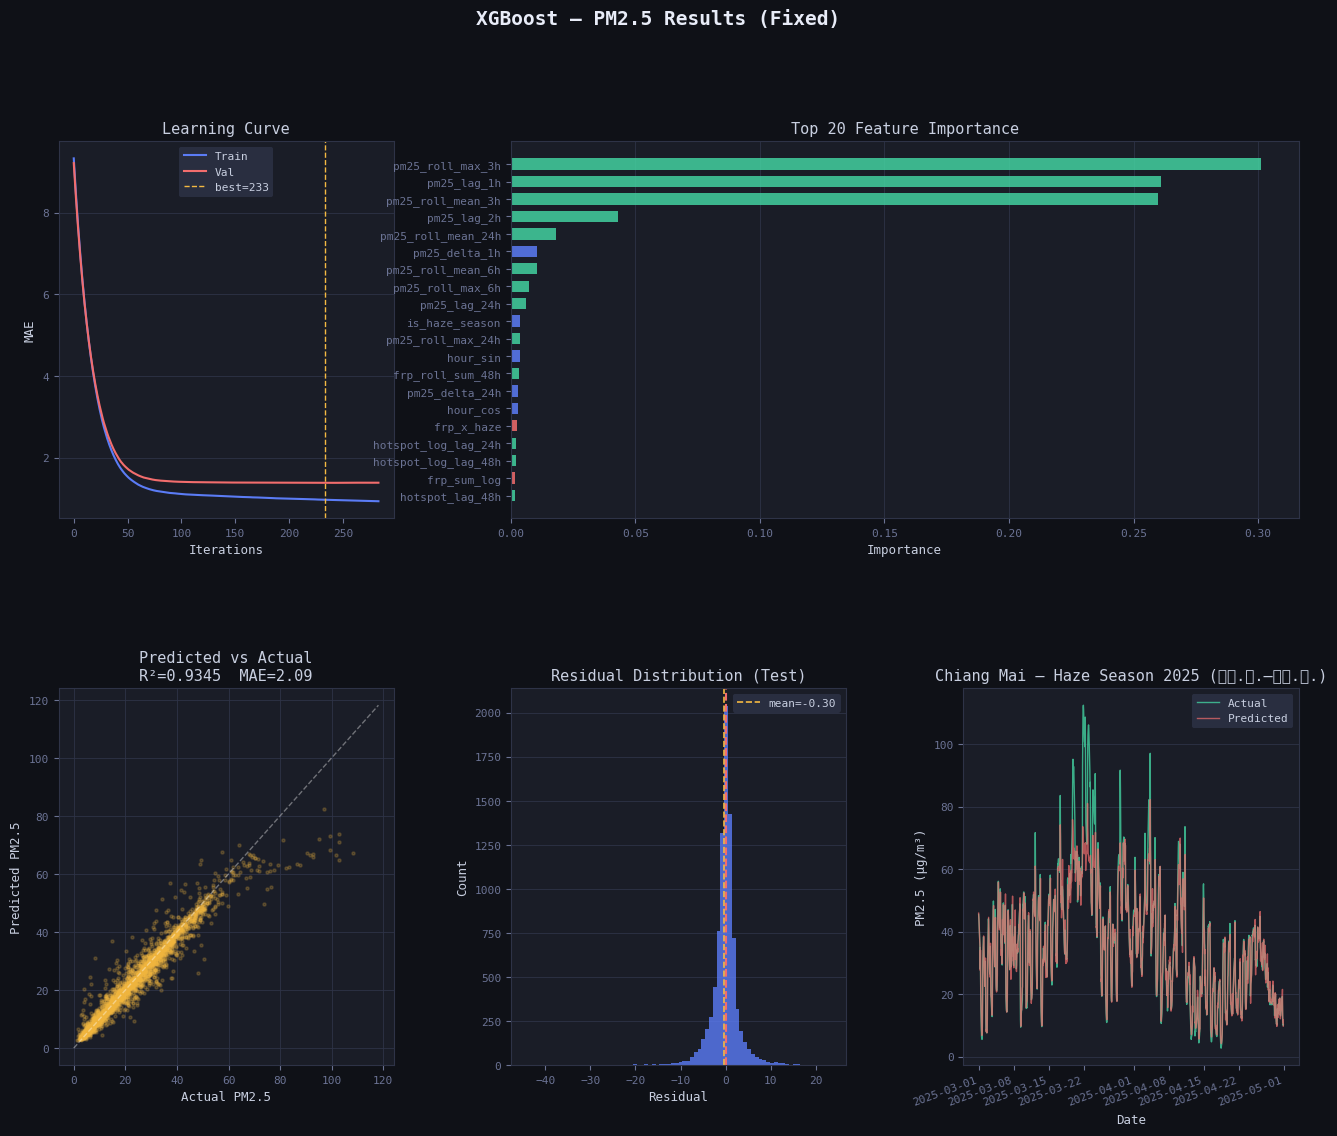

In [30]:
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("XGBoost — PM2.5 Results (Fixed)", fontsize=14,
             color="#e8ecf8", fontweight="bold", y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# Learning curve
ax = fig.add_subplot(gs[0, 0])
res = model.evals_result()
ax.plot(res["validation_0"]["mae"], color=ACCENT,  lw=1.5, label="Train")
ax.plot(res["validation_1"]["mae"], color=ACCENT2, lw=1.5, label="Val")
ax.axvline(model.best_iteration, color=ACCENT4, lw=1, ls="--",
           label=f"best={model.best_iteration}")
ax.set_xlabel("Iterations"); ax.set_ylabel("MAE")
ax.set_title("Learning Curve")
ax.legend(fontsize=8, facecolor=PALE, edgecolor="none")
ax.yaxis.grid(True); ax.set_axisbelow(True)
 
# Feature importance top 20
ax = fig.add_subplot(gs[0, 1:])
fi = pd.DataFrame({"feature": ALL_FEATURES,
                   "importance": model.feature_importances_}
                  ).sort_values("importance", ascending=False)
top20 = fi.head(20).iloc[::-1]
colors_fi = [ACCENT3 if "lag" in c or "roll" in c
             else (ACCENT2 if any(x in c for x in ["hotspot","frp"]) else ACCENT)
             for c in top20["feature"]]
ax.barh(top20["feature"], top20["importance"], color=colors_fi, alpha=0.85, height=0.65)
ax.set_xlabel("Importance"); ax.set_title("Top 20 Feature Importance")
ax.xaxis.grid(True); ax.set_axisbelow(True)
 
# Predicted vs Actual
ax = fig.add_subplot(gs[1, 0])
idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
ax.scatter(y_test.iloc[idx], pred_test[idx], alpha=0.2, s=5,
           color=ACCENT4, rasterized=True)
lim = max(y_test.max(), pred_test.max()) * 1.05
ax.plot([0, lim], [0, lim], color="#ffffff60", lw=1, ls="--")
ax.set_xlabel("Actual PM2.5"); ax.set_ylabel("Predicted PM2.5")
ax.set_title(f"Predicted vs Actual\nR²={m_test['r2']:.4f}  MAE={m_test['mae']:.2f}")
ax.yaxis.grid(True); ax.xaxis.grid(True); ax.set_axisbelow(True)
 
# Residual distribution
ax = fig.add_subplot(gs[1, 1])
residuals = pred_test - y_test.values
ax.hist(residuals, bins=80, color=ACCENT, alpha=0.8, edgecolor="none")
ax.axvline(0, color=ACCENT2, lw=1.5, ls="--")
ax.axvline(residuals.mean(), color=ACCENT4, lw=1.2, ls="--",
           label=f"mean={residuals.mean():.2f}")
ax.set_xlabel("Residual"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution (Test)")
ax.legend(fontsize=8, facecolor=PALE, edgecolor="none")
ax.yaxis.grid(True); ax.set_axisbelow(True)
 
# Time series — Chiang Mai haze season 2025
ax = fig.add_subplot(gs[1, 2])
df_test_feat["pred"] = pred_test
cm = df_test_feat[
    (df_test_feat["Province"] == "Chiang Mai") &
    (df_test_feat["Datetime"].dt.month.isin([3, 4]))
].sort_values("Datetime")
if len(cm) > 0:
    ax.plot(cm["Datetime"], cm[TARGET], color=ACCENT3, lw=1, alpha=0.8, label="Actual")
    ax.plot(cm["Datetime"], cm["pred"],  color=ACCENT2, lw=1, alpha=0.7, label="Predicted")
    ax.set_xlabel("Date"); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title("Chiang Mai — Haze Season 2025 (มี.ค.–เม.ย.)")
    ax.legend(fontsize=8, facecolor=PALE, edgecolor="none")
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha="right")
 
plt.savefig("xgb_results_fixed.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("  Saved: xgb_results_fixed.png")
plt.show()

In [31]:
# ============================================================
# 8. SAVE
# ============================================================
print("\n[8] Saving...")
 
model.save_model("xgb_pm25.json")
 
out = df_test_feat[["Datetime", "Province", TARGET]].copy()
out["predicted"] = pred_test
out["residual"]  = pred_test - out[TARGET]
out.to_csv("xgb_predictions_test.csv", index=False)
 
feat_dict = {
    "ALL_FEATURES":     ALL_FEATURES,
    "STATIC_FEATURES":  STATIC_FEATURES,
    "LAG_FEATURES":     LAG_FEATURES,
    "ROLLING_FEATURES": ROLLING_FEATURES,
    "DELTA_FEATURES":   DELTA_FEATURES,
    "TARGET":           TARGET,
}
with open("pm25_features.json", "w") as f:
    json.dump(feat_dict, f, indent=2, ensure_ascii=False)
 
print("  xgb_pm25.json")
print("  xgb_predictions_test.csv")
print("  xgb_results_fixed.png")
print("  pm25_features.json")
 
print("\n" + "=" * 60)
print("  เสร็จสมบูรณ์")
print("=" * 60)


[8] Saving...
  xgb_pm25.json
  xgb_predictions_test.csv
  xgb_results_fixed.png
  pm25_features.json

  เสร็จสมบูรณ์


In [33]:
import shap

# คำนวณ SHAP values บน test set
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# 1. SHAP summary plot
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()

# 2. Bar plot - feature importance แบบ SHAP (mean ||SHAP| value)
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.close()

# 3. Dependence plot - ดูความสัมพันธ์ระหว่าง feature ที่สำคัญที่สุดกับ SHAP value
shap.dependence_plot("pm25_lag_1h", shap_values.values, X_test, show=False)
plt.savefig("shap_dependence_lag1h.png", dpi=150, bbox_inches="tight")
plt.close()

# 4. Waterfall - อธิบาย prediction เดียว 1 row (เช่น row ที่มี PM2.5 สูงสุดใน test set)
worst_idx  = y_test.values.argmax()
shap_exp = shap.Explanation(
    values = shap_values[worst_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[worst_idx],
    feature_names = ALL_FEATURES
)
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.savefig("shap_waterfall_worst.png", dpi=150, bbox_inches="tight")
plt.close()

print("SHAP plots saved.")


SHAP plots saved.
